In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, SimpleRNN, BatchNormalization, Bidirectional, Attention, GlobalAveragePooling1D, Add, MultiHeadAttention
from tensorflow.keras.utils import to_categorical
from tcn import TCN
from sklearn.preprocessing import RobustScaler
from sklearn.utils import class_weight
import matplotlib.cm as cm
from sklearn.utils.class_weight import compute_class_weight
import requests

ModuleNotFoundError: No module named 'pandas_ta'

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Distribution des classes :
target
2.0    400
1.0    388
0.0    248
Name: count, dtype: int64
Class weights: {np.int64(0): np.float64(1.3533333333333333), np.int64(1): np.float64(0.973621103117506), np.int64(2): np.float64(0.810379241516966)}
X_train: (812, 21, 17), X_test: (203, 21, 17), features: 17
🚀 Training SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
🚀 Training LSTM...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
🚀 Training CNN-LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step
🚀 Training Conv-Attention...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
🚀 Training Hybrid-LSTM-GRU...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
🚀 Training Bi-GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
🚀 Training Deep-Dense...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
🚀 Training Attention-TCN-GRU...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


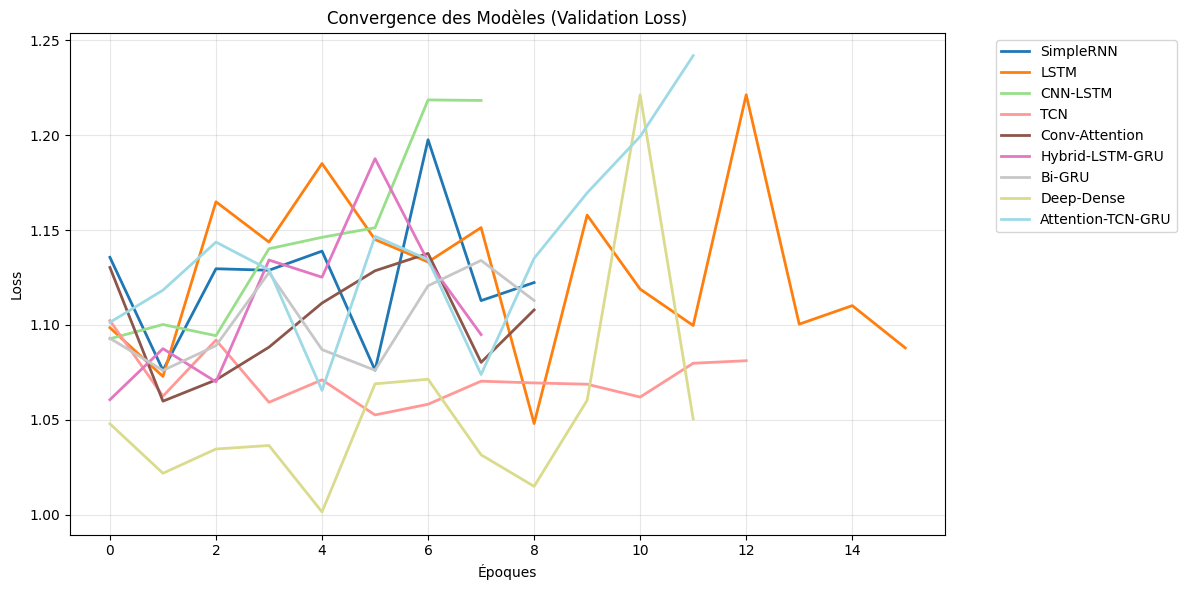


Rang  Modèle                  P(SELL)  P(HOLD)   P(BUY)    Conf.  Entropie
1     LSTM                     0.3248   0.3871   0.2882   0.4935    1.0239   → favori: HOLD ⚠️  (trop plat)
2     Deep-Dense               0.2546   0.4501   0.2952   0.4683    1.0368   → favori: HOLD ⚠️  (trop plat)
3     SimpleRNN                0.3321   0.3603   0.3075   0.4239    1.0702   → favori: HOLD ⚠️  (trop plat)
4     TCN                      0.3164   0.3747   0.3089   0.3985    1.0842   → favori: HOLD ⚠️  (trop plat)
5     Attention-TCN-GRU        0.3052   0.3734   0.3214   0.3936    1.0854   → favori: HOLD ⚠️  (trop plat)
6     Conv-Attention           0.3024   0.3511   0.3466   0.3907    1.0820   → favori: HOLD ⚠️  (trop plat)
7     Bi-GRU                   0.3374   0.3621   0.3005   0.3852    1.0905   → favori: HOLD ⚠️  (trop plat)
8     Hybrid-LSTM-GRU          0.2978   0.3608   0.3414   0.3675    1.0935   → favori: HOLD ⚠️  (trop plat)
9     CNN-LSTM                 0.3257   0.3359   0.3384   0.

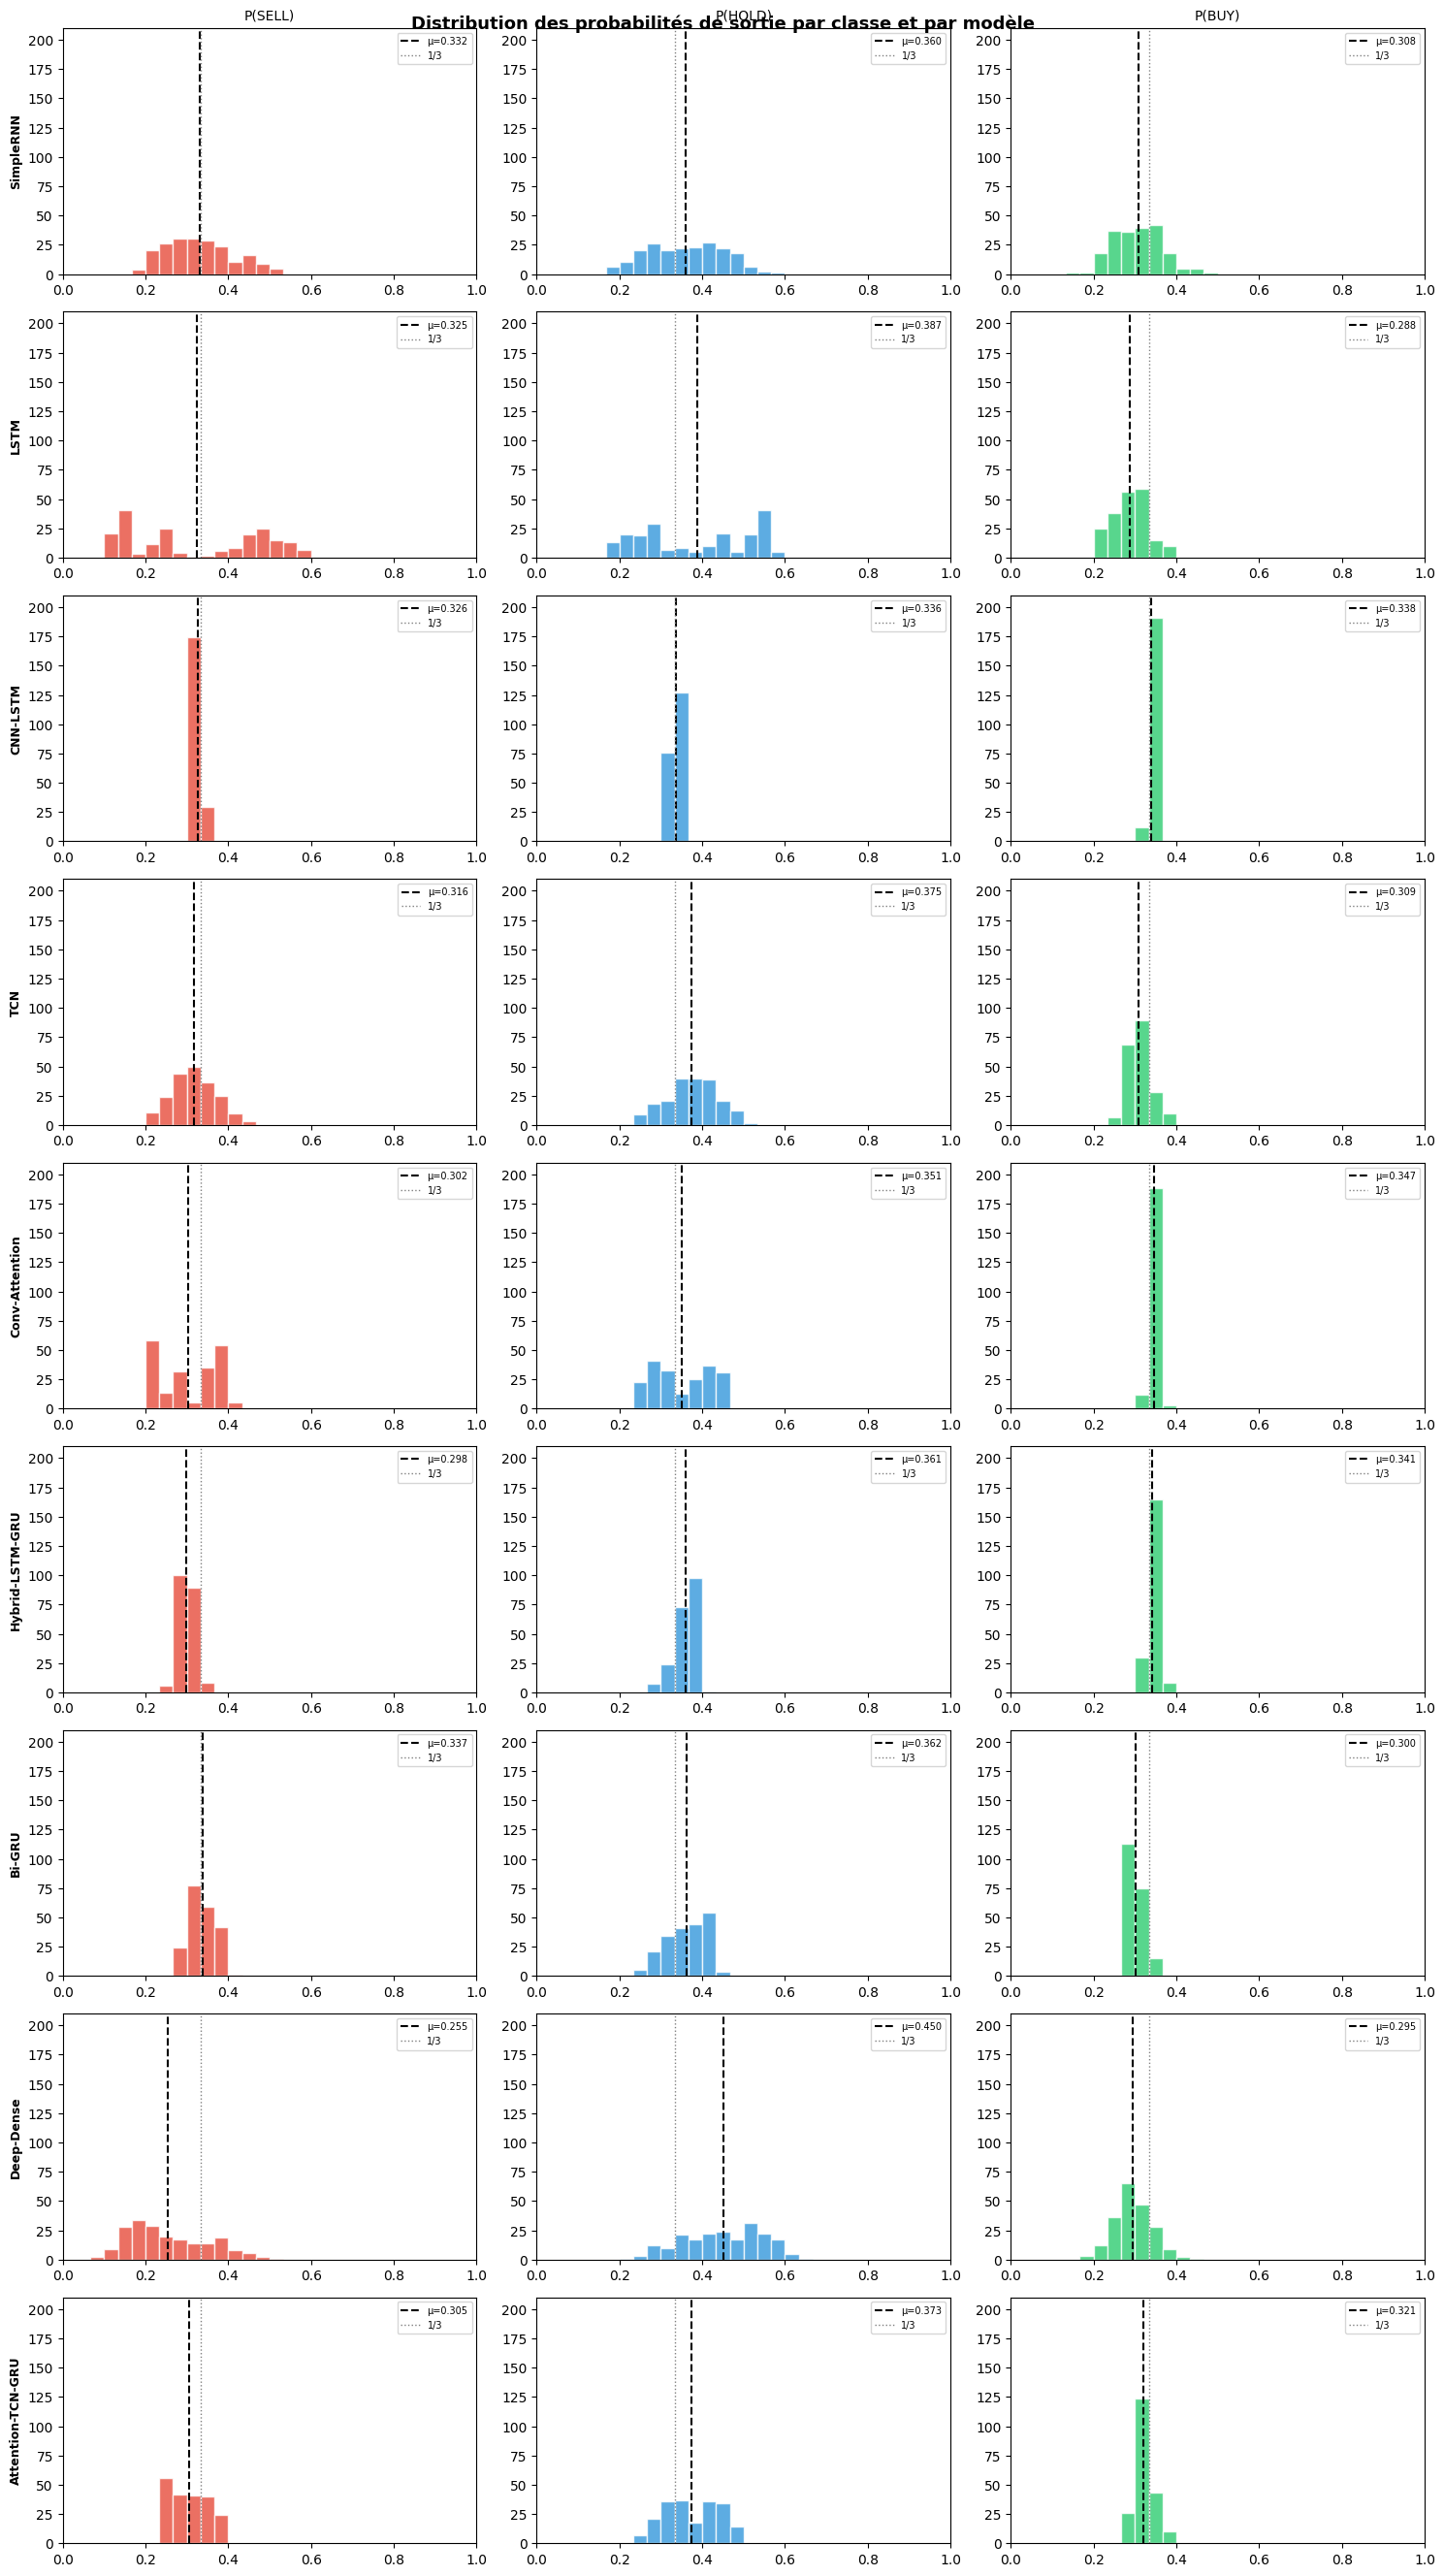

In [ ]:
# --- 1. CONFIGURATION ---
TICKER = "SPY"
WINDOW_SIZE = 21
HORIZON = 7
THRESHOLD = 0.0119   # 0.0 = binaire (hausse/baisse), >0 = triple barrière avec HOLD

# --- 2. PRÉPARATION DES DONNÉES ---
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- Features originales ---
df['returns']    = df['Close'].pct_change()
df['RSI']        = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

macd           = ta.macd(df['Close'])
df['MACD']     = macd.iloc[:, 0] / df['Close']

stoch          = ta.stoch(df['High'], df['Low'], df['Close'])
df['STOCH']    = stoch.iloc[:, 0] / 100

bbands         = ta.bbands(df['Close'], length=20, std=2)
df['BB_width'] = (bbands.iloc[:, 2] - bbands.iloc[:, 0]) / df['Close']

adx            = ta.adx(df['High'], df['Low'], df['Close'])
df['ADX']      = adx.iloc[:, 0] / 100

# --- Features enrichies ---
df['volume_change']   = df['Volume'].pct_change()
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['high_low_range']  = (df['High'] - df['Low']) / df['Close']
df['close_position']  = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['momentum_3']      = df['Close'].pct_change(3)
df['momentum_7']      = df['Close'].pct_change(7)
df['momentum_14']     = df['Close'].pct_change(14)

# VIX
vix_raw = yf.download("^VIX", start="2018-01-01", auto_adjust=True)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw['Close'].copy()
vix.index = pd.to_datetime(vix.index).tz_localize(None)
df.index = pd.to_datetime(df.index).tz_localize(None)
df['vix'] = vix.reindex(df.index).ffill() / 100

# Taux 10 ans US
tnx_raw = yf.download("^TNX", start="2018-01-01", auto_adjust=True)
if isinstance(tnx_raw.columns, pd.MultiIndex):
    tnx_raw.columns = tnx_raw.columns.get_level_values(0)
tnx = tnx_raw['Close'].copy()
tnx.index = pd.to_datetime(tnx.index).tz_localize(None)
df['tnx'] = tnx.reindex(df.index).ffill() / 100

# Fear & Greed
fg = requests.get("https://api.alternative.me/fng/?limit=2000&format=json").json()
fg_df = pd.DataFrame(fg['data'])
fg_df['timestamp'] = pd.to_datetime(fg_df['timestamp'].astype(int), unit='s')
fg_df = fg_df.set_index('timestamp')[['value']].rename(columns={'value': 'fear_greed'})
fg_df['fear_greed'] = fg_df['fear_greed'].astype(float) / 100
df = df.join(fg_df, how='left')
df['fear_greed'] = df['fear_greed'].ffill()

df.dropna(inplace=True)

# --- Labeling ---
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

if THRESHOLD == 0.0:
    # Binaire : 1 = hausse, 0 = baisse — pas de HOLD
    NUM_CLASSES = 2
    def labeler(x):
        if pd.isna(x): return None
        return 1 if x > 0 else 0
    CLASS_NAMES = ["SELL", "BUY"]
else:
    # Triple barrière
    NUM_CLASSES = 3
    def labeler(x):
        if pd.isna(x): return None
        if x >  THRESHOLD: return 2
        if x < -THRESHOLD: return 0
        return 1
    CLASS_NAMES = ["SELL", "HOLD", "BUY"]

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Distribution des classes :\n{df['target'].value_counts()}")

# --- Séquençage ---
features = [
    'returns', 'RSI', 'Volatility', 'ADX', 'MACD', 'STOCH', 'BB_width',
    'volume_change', 'volume_ma_ratio', 'high_low_range', 'close_position',
    'momentum_3', 'momentum_7', 'momentum_14',
    'vix', 'tnx', 'fear_greed'
]

X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

# --- Split temporel ---
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels   = y[split:]

# --- Class weights ---
classes       = np.unique(y[:split])
weights_array = compute_class_weight('balanced', classes=classes, y=y[:split])
class_weights = dict(zip(classes.astype(int), weights_array))
print(f"Class weights: {class_weights}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, features: {len(features)}")


# --- 3. ARCHITECTURES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs   = Input(shape=(WINDOW_SIZE, len(features)))
    x        = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    query    = Dense(64)(x)
    value    = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x        = GlobalAveragePooling1D()(attn_out)
    outputs  = Dense(NUM_CLASSES, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_attention_tcn_gru():
    inputs   = Input(shape=(WINDOW_SIZE, len(features)))
    tcn_out  = TCN(nb_filters=64, kernel_size=3, dilations=[1, 2, 4],
                   return_sequences=True, dropout_rate=0.1)(inputs)
    gru_out  = Bidirectional(GRU(64, return_sequences=True))(inputs)
    query    = Dense(128)(tcn_out)
    value    = Dense(128)(gru_out)
    attn_out = Attention()([query, value])
    pooled   = GlobalAveragePooling1D()(attn_out)
    x        = Dense(32, activation='relu')(pooled)
    x        = Dropout(0.2)(x)
    output   = Dense(NUM_CLASSES, activation='softmax')(x)
    m = Model(inputs=inputs, outputs=output)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT ---

model_factories = {
    "SimpleRNN":         build_rnn,
    "LSTM":              build_lstm,
    "CNN-LSTM":          build_cnn_lstm,
    "TCN":               build_tcn,
    "Conv-Attention":    build_conv_attention,
    "Hybrid-LSTM-GRU":   build_hybrid_lstm_gru,
    "Bi-GRU":            build_bigru,
    "Deep-Dense":        build_deep_dense,
    "Attention-TCN-GRU": build_attention_tcn_gru,
}

model_names    = list(model_factories.keys())
color_palette  = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map      = dict(zip(model_names, color_palette))

proba_results  = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    h = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        class_weight=class_weights,
        callbacks=[es],
        verbose=0
    )
    probas = model.predict(X_test)
    proba_results[name] = probas
    plt.plot(h.history['val_loss'], label=name, color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 5. ANALYSE DES PROBAS & CLASSEMENT ---

summary = []
for name, probas in proba_results.items():
    means    = [probas[:, i].mean() for i in range(NUM_CLASSES)]
    max_conf = probas.max(axis=1).mean()
    entropy  = -(probas * np.log(probas + 1e-10)).sum(axis=1).mean()
    entry = {"name": name, "max_conf": max_conf, "entropy": entropy}
    for i, cls in enumerate(CLASS_NAMES):
        entry[f"mean_{cls}"] = means[i]
    summary.append(entry)

summary_sorted = sorted(summary, key=lambda x: x["max_conf"], reverse=True)

header = f"{'Rang':<5} {'Modèle':<22}" + "".join(f" {'P('+c+')':>8}" for c in CLASS_NAMES) + f" {'Conf.':>8} {'Entropie':>9}"
print("\n" + "="*len(header))
print(header)
print("="*len(header))
for i, s in enumerate(summary_sorted):
    flag     = " ⚠️  (trop plat)" if s["max_conf"] < 0.55 else ""
    dominant = CLASS_NAMES[np.argmax([s[f"mean_{c}"] for c in CLASS_NAMES])]
    proba_str = "".join(f" {s[f'mean_{c}']:>8.4f}" for c in CLASS_NAMES)
    print(f"{i+1:<5} {s['name']:<22}{proba_str} {s['max_conf']:>8.4f} {s['entropy']:>9.4f}   → favori: {dominant}{flag}")
print("="*len(header))
print("Conf. = confiance moy. (max des probas). Entropie ↓ = modèle plus décidé.")
if NUM_CLASSES == 2:
    print("Mode BINAIRE actif (THRESHOLD=0) : SELL=baisse, BUY=hausse, pas de HOLD.")


# --- 6. VISUALISATION ---

n_models = len(proba_results)
fig, axes = plt.subplots(n_models, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 3 * n_models))
fig.suptitle("Distribution des probabilités de sortie par classe et par modèle", fontsize=13, fontweight='bold')

colors_cls = ['#e74c3c', '#3498db', '#2ecc71'][:NUM_CLASSES]

global_max_count = 0
for probas in proba_results.values():
    for col in range(NUM_CLASSES):
        counts, _ = np.histogram(probas[:, col], bins=30, range=(0, 1))
        global_max_count = max(global_max_count, counts.max())

for row, (name, probas) in enumerate(proba_results.items()):
    for col, (cls, color) in enumerate(zip(CLASS_NAMES, colors_cls)):
        ax = axes[row, col] if n_models > 1 else axes[col]
        ax.hist(probas[:, col], bins=30, range=(0, 1), color=color, alpha=0.8, edgecolor='white')
        mu = probas[:, col].mean()
        ax.axvline(mu,          color='black', linestyle='--', linewidth=1.5, label=f"μ={mu:.3f}")
        ax.axvline(1/NUM_CLASSES, color='grey', linestyle=':',  linewidth=1,   label=f"1/{NUM_CLASSES}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, global_max_count * 1.1)
        if col == 0:
            ax.set_ylabel(name, fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(f"P({cls})", fontsize=10)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
results_high_conf = []

for name, probas in proba_results.items():
    # On définit le seuil de confiance
    threshold = 0.60
    
    # Masque pour les prédictions dont la probabilité max > threshold
    mask = np.max(probas, axis=1) > threshold
    
    if np.sum(mask) > 0:
        preds = np.argmax(probas[mask], axis=1)
        actuals = y_test_labels[mask]
        acc = accuracy_score(actuals, preds)
        count = np.sum(mask)
    else:
        acc = 0
        count = 0
        
    results_high_conf.append({
        "Modèle": name,
        "Accuracy (>60%)": f"{acc:.2%}",
        "Nombre de trades": count
    })

# Affichage du classement par précision sur signaux forts
import pandas as pd
df_high_conf = pd.DataFrame(results_high_conf).sort_values(by="Accuracy (>60%)", ascending=False)
print(df_high_conf)

              Modèle Accuracy (>60%)  Nombre de trades
7         Deep-Dense          50.00%                 6
0          SimpleRNN           0.00%                 0
1               LSTM           0.00%                 0
2           CNN-LSTM           0.00%                 0
3                TCN           0.00%                 0
4     Conv-Attention           0.00%                 0
5    Hybrid-LSTM-GRU           0.00%                 0
6             Bi-GRU           0.00%                 0
8  Attention-TCN-GRU           0.00%                 0


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 1. Préparation spécifique : on aplatit les fenêtres temporelles
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Le SVM est très sensible à l'échelle des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# 3. Entraînement avec gestion du déséquilibre (class_weight)
print("🚀 Training SVM (RBF Kernel)...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced')
svm_model.fit(X_train_scaled, y[:split]) # On utilise y non-categorical pour sklearn

# 4. Prédiction des probabilités pour ton tableau de comparaison
probas_svm = svm_model.predict_proba(X_test_scaled)

🚀 Training SVM (RBF Kernel)...


In [ ]:
print(probas_svm)

[[0.06087332 0.44391506 0.49521162]
 [0.11861576 0.48338045 0.39800379]
 [0.16288619 0.45700818 0.38010563]
 [0.27674769 0.4639095  0.25934281]
 [0.2269282  0.57153864 0.20153316]
 [0.43507879 0.42715057 0.13777064]
 [0.36167687 0.49343701 0.14488612]
 [0.44139901 0.44913369 0.1094673 ]
 [0.33192993 0.52092089 0.14714918]
 [0.37728612 0.48987398 0.1328399 ]
 [0.30075404 0.52065903 0.17858694]
 [0.40158542 0.44717888 0.1512357 ]
 [0.39120251 0.45104717 0.15775033]
 [0.42593178 0.42822671 0.14584151]
 [0.20090792 0.59279691 0.20629517]
 [0.2131523  0.54231435 0.24453335]
 [0.11574253 0.64109551 0.24316196]
 [0.11869689 0.63798182 0.24332129]
 [0.05055589 0.71956049 0.22988362]
 [0.06291761 0.69058341 0.24649898]
 [0.05976242 0.67762339 0.2626142 ]
 [0.17254393 0.54906249 0.27839358]
 [0.16916004 0.56744782 0.26339214]
 [0.27697442 0.49319461 0.22983097]
 [0.17175808 0.53084786 0.29739406]
 [0.18961067 0.48382887 0.32656046]
 [0.11642545 0.57726043 0.30631412]
 [0.15255697 0.43287338 0.41

In [ ]:
# On ne garde que les moments où le SVM est "sûr" (> 60%)
high_conf_idx = np.where(probas_svm.max(axis=1) > 0.60)[0]
y_pred_high_conf = np.argmax(probas_svm[high_conf_idx], axis=1)
y_true_high_conf = y_test_labels[high_conf_idx]

from sklearn.metrics import accuracy_score
if len(high_conf_idx) > 0:
    print(f"Accuracy sur signaux forts (>60%): {accuracy_score(y_true_high_conf, y_pred_high_conf):.2%}")
    print(f"Nombre de trades identifiés : {len(high_conf_idx)}")
else:
    print("Aucun signal assez fort.")

Accuracy sur signaux forts (>60%): 52.38%
Nombre de trades identifiés : 21


In [ ]:
# 1. On récupère les indices des signaux forts
high_conf_mask = probas_svm.max(axis=1) > 0.60
trades_idx = np.where(high_conf_mask)[0]

# 2. On crée un DataFrame de performance
df_test = df.iloc[split + WINDOW_SIZE:].copy()
df_test = df_test.iloc[trades_idx]

df_test['pred'] = np.argmax(probas_svm[high_conf_mask], axis=1)
df_test['real_change'] = (df['Close'].shift(-HORIZON) / df['Close'] - 1).iloc[split + WINDOW_SIZE + trades_idx].values

# 3. Calcul du profit (simplifié)
# On gagne si (pred=2 et change > THRESHOLD) ou (pred=0 et change < -THRESHOLD)
def calculate_profit(row):
    if row['pred'] == 2: return row['real_change'] # Long
    if row['pred'] == 0: return -row['real_change'] # Short
    return 0

df_test['profit'] = df_test.apply(calculate_profit, axis=1)

print(f"Profit cumulé sur 21 trades : {df_test['profit'].sum():.2%}")
print(f"Profit moyen par trade : {df_test['profit'].mean():.2%}")

Profit cumulé sur 21 trades : -7.36%
Profit moyen par trade : -0.37%



Modèle                  Cash investi  Valeur finale  Valeur tot.  Alpha (€)  Skip   Dbl
                                           (pf + cash gardé)
DCA Naïf                      19600€         20001€            —          0€  —     —
------------------------------------------------------------------------------------------
Conv-Attention                19600€         20536€       20536€       +535€    0    81 🏆
Deep-Dense                    19600€         20525€       20525€       +524€    3    61 🏆
CNN-LSTM                      19600€         20296€       20296€       +295€    0    25 🏆
Bi-GRU                        19600€         20198€       20198€       +197€   15    23 🏆
SimpleRNN                     19600€         20163€       20163€       +162€   19    24 🏆
Hybrid-LSTM-GRU               19600€         20153€       20153€       +152€   13    18 🏆
TCN                           19600€         20118€       20118€       +117€    9    22 🏆
LSTM                          19600€       

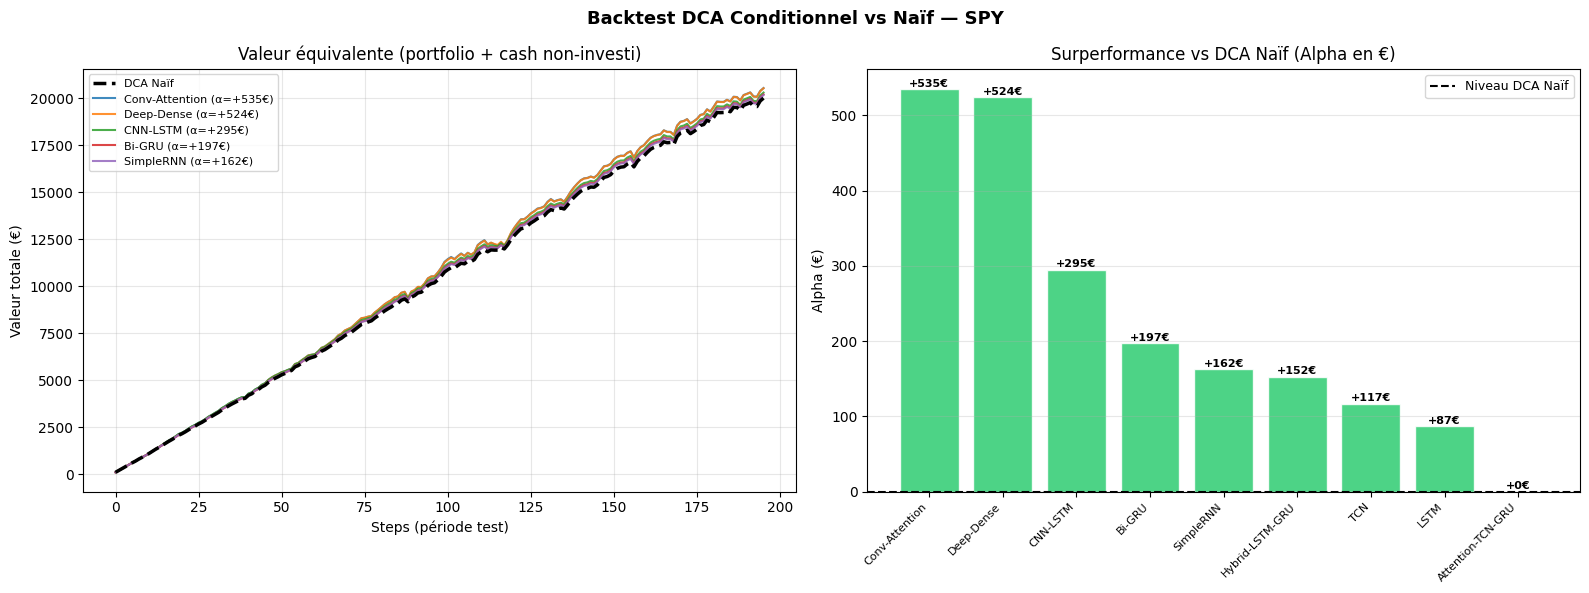

In [ ]:
# --- BACKTEST DCA CONDITIONNEL ---

import matplotlib.pyplot as plt
import numpy as np

# --- CONFIG ---
BUDGET_PERIODIQUE = 100   # € investis par candle (horaire ici)
CONFIANCE_MIN     = 0.60  # seuil de confiance pour agir
DOUBLE_SI_BUY     = True
SKIP_SI_SELL      = True

# --- ALIGNEMENT PRIX / PROBAS ---
close_test = df['Close'].values[WINDOW_SIZE:]
close_test = close_test[split:]
min_len    = min(len(close_test), min(len(p) for p in proba_results.values()))
close_test = close_test[:min_len]

# Nombre fixe de steps pour tout le monde (base de comparaison équitable)
N_STEPS = min_len - HORIZON


def run_dca_naive(close_prices, n_steps, budget=BUDGET_PERIODIQUE):
    cash, units = 0.0, 0.0
    pf_values, cash_hist = [], []
    for i in range(n_steps):
        units += budget / close_prices[i]
        cash  += budget
        pf_values.append(units * close_prices[i])
        cash_hist.append(cash)
    return {
        "name":             "DCA Naïf",
        "valeur_finale":    pf_values[-1],
        "cash_investi":     cash,
        "portfolio_values": pf_values,
        "cash_history":     cash_hist,
        "n_skip": 0, "n_double": 0, "n_normal": n_steps,
    }


def run_dca_backtest(probas, close_prices, name, n_steps, budget=BUDGET_PERIODIQUE):
    probas = probas[:min_len]
    cash, units = 0.0, 0.0
    pf_values, cash_hist, decisions = [], [], []

    for i in range(n_steps):
        p        = probas[i]
        conf     = p.max()
        signal   = np.argmax(p)
        confiant = conf >= CONFIANCE_MIN

        if NUM_CLASSES == 2:
            is_buy  = (signal == 1) and confiant
            is_sell = (signal == 0) and confiant
        else:
            is_buy  = (signal == 2) and confiant
            is_sell = (signal == 0) and confiant

      # Dans run_dca_backtest, remplace la logique de montant par :
        cash_restant = (n_steps * budget) - cash  # budget total restant
        if cash_restant <= 0:
            montant, dec = 0.0, "EPUISE"
        elif is_sell and SKIP_SI_SELL:
            montant, dec = 0.0, "SKIP"
        elif is_buy and DOUBLE_SI_BUY:
            montant, dec = min(budget * 2, cash_restant), "DOUBLE"
        else:
            montant, dec = min(budget, cash_restant), "NORMAL"

        units += montant / close_prices[i]
        cash  += montant
        decisions.append(dec)
        pf_values.append(units * close_prices[i])
        cash_hist.append(cash)

    valeur_finale = pf_values[-1]

    # --- Métrique normalisée ---
    # On compare à combien on aurait eu avec le même cash qu'un DCA naïf
    cash_naif        = n_steps * budget
    # Performance relative : combien de % de plus (ou moins) que le naïf
    # en supposant que le cash non-investi (skips) reste en poche sans rendement
    cash_non_investi = cash_naif - cash
    valeur_equivalente = valeur_finale + cash_non_investi  # total wealth
    valeur_naif_ref    = run_dca_naive(close_prices, n_steps, budget)["valeur_finale"]
    alpha              = valeur_equivalente - valeur_naif_ref  # € de surperformance

    return {
        "name":               name,
        "valeur_finale":      valeur_finale,
        "valeur_equivalente": valeur_equivalente,
        "cash_investi":       cash,
        "cash_naif":          cash_naif,
        "alpha_eur":          alpha,
        "n_skip":             decisions.count("SKIP"),
        "n_double":           decisions.count("DOUBLE"),
        "n_normal":           decisions.count("NORMAL"),
        "portfolio_values":   pf_values,
        "cash_history":       cash_hist,
    }


# --- RUN ---
naive      = run_dca_naive(close_test, N_STEPS)
results_bt = [run_dca_backtest(probas, close_test, name, N_STEPS)
              for name, probas in proba_results.items()]

# Trier par alpha (surperformance vs naïf) — métrique cohérente
results_bt_sorted = sorted(results_bt, key=lambda x: x["alpha_eur"], reverse=True)

# --- TABLEAU ---
print("\n" + "="*90)
print(f"{'Modèle':<22} {'Cash investi':>13} {'Valeur finale':>14} {'Valeur tot.':>12} {'Alpha (€)':>10} {'Skip':>5} {'Dbl':>5}")
print(f"{'':42} {'(pf + cash gardé)':>12}")
print("="*90)
print(f"{'DCA Naïf':<22} {naive['cash_investi']:>12.0f}€ {naive['valeur_finale']:>13.0f}€ "
      f"{'—':>12} {'0':>10}€  —     —")
print("-"*90)
for r in results_bt_sorted:
    flag = " 🏆" if r["alpha_eur"] > 0 else " ❌"
    print(
        f"{r['name']:<22} {r['cash_investi']:>12.0f}€ {r['valeur_finale']:>13.0f}€ "
        f"{r['valeur_equivalente']:>11.0f}€ {r['alpha_eur']:>+10.0f}€"
        f"  {r['n_skip']:>3}   {r['n_double']:>3}{flag}"
    )
print("="*90)
print("Alpha = (valeur_finale + cash_non_investi) - valeur_naïf  →  surperformance réelle")
print(f"Référence DCA Naïf : valeur finale = {naive['valeur_finale']:.0f}€ pour {naive['cash_investi']:.0f}€ investis")


# --- VISUALISATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Backtest DCA Conditionnel vs Naïf — {TICKER}", fontsize=13, fontweight='bold')
cmap  = plt.get_cmap('tab10')
steps = np.arange(N_STEPS)

# Plot 1 : Valeur équivalente (pf + cash gardé) dans le temps
ax1 = axes[0]
ax1.plot(steps, naive['portfolio_values'], color='black', linewidth=2.5,
         linestyle='--', label='DCA Naïf', zorder=10)

for i, r in enumerate(results_bt_sorted[:5]):
    # Valeur équivalente à chaque step
    cash_naif_step = (np.arange(N_STEPS) + 1) * BUDGET_PERIODIQUE
    cash_investi_step = np.array(r['cash_history'])
    cash_garde_step   = cash_naif_step - cash_investi_step
    val_eq_step       = np.array(r['portfolio_values']) + cash_garde_step
    ax1.plot(steps, val_eq_step, color=cmap(i), linewidth=1.5, alpha=0.85,
             label=f"{r['name']} (α={r['alpha_eur']:+.0f}€)")

ax1.set_title("Valeur équivalente (portfolio + cash non-investi)")
ax1.set_xlabel("Steps (période test)")
ax1.set_ylabel("Valeur totale (€)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2 : Alpha final (surperformance en €)
ax2 = axes[1]
names_plot  = [r["name"] for r in results_bt_sorted]
alphas      = [r["alpha_eur"] for r in results_bt_sorted]
colors_bar  = ['#2ecc71' if a > 0 else '#e74c3c' for a in alphas]

bars = ax2.bar(names_plot, alphas, color=colors_bar, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Niveau DCA Naïf')

for bar, val in zip(bars, alphas):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.5 if val >= 0 else -1.5),
             f"{val:+.0f}€", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_title("Surperformance vs DCA Naïf (Alpha en €)")
ax2.set_ylabel("Alpha (€)")
ax2.set_xticks(range(len(names_plot)))
ax2.set_xticklabels(names_plot, rotation=45, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# --- VOIE 2 : DONNÉES INTRADAY HOURLY ---
# Remplace entièrement ton bloc de configuration + données.
# Le reste du code (architectures, entraînement, analyse) reste identique.

# --- 1. CONFIGURATION INTRADAY ---
TICKER      = "SPY"
INTERVAL    = "1h"        # hourly
PERIOD      = "2y"        # max disponible sur yfinance pour le hourly
WINDOW_SIZE = 24 * 5      # 5 jours de lookback (24h * 5)
HORIZON     = 24 * 5      # prédit dans 5 jours ouvrés (~1 semaine)
THRESHOLD   = 0.035        # 1% sur SPY
NUM_CLASSES = 3
CLASS_NAMES = ["SELL", "HOLD", "BUY"]

# --- 2. DONNÉES HORAIRES ---
df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Supprime les heures hors marché (pre/after market partiel)
df = df.between_time("09:30", "16:00")
df.index = df.index.tz_localize(None)

print(f"Données horaires : {len(df)} candles sur {PERIOD}")

# --- Features techniques ---
df['returns']    = df['Close'].pct_change()
df['RSI']        = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

macd           = ta.macd(df['Close'])
df['MACD']     = macd.iloc[:, 0] / df['Close']

stoch          = ta.stoch(df['High'], df['Low'], df['Close'])
df['STOCH']    = stoch.iloc[:, 0] / 100

bbands         = ta.bbands(df['Close'], length=20, std=2)
df['BB_width'] = (bbands.iloc[:, 2] - bbands.iloc[:, 0]) / df['Close']

adx            = ta.adx(df['High'], df['Low'], df['Close'])
df['ADX']      = adx.iloc[:, 0] / 100

df['volume_change']   = df['Volume'].pct_change()
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['high_low_range']  = (df['High'] - df['Low']) / df['Close']
df['close_position']  = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['momentum_3']      = df['Close'].pct_change(3)
df['momentum_7']      = df['Close'].pct_change(7)
df['momentum_14']     = df['Close'].pct_change(14)

# VIX horaire (proxy : on reindex le daily sur les timestamps horaires)
vix_raw = yf.download("^VIX", period=PERIOD, interval="1d", auto_adjust=True)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix_raw.index = pd.to_datetime(vix_raw.index).tz_localize(None)
df['vix'] = vix_raw['Close'].reindex(df.index, method='ffill') / 100

tnx_raw = yf.download("^TNX", period=PERIOD, interval="1d", auto_adjust=True)
if isinstance(tnx_raw.columns, pd.MultiIndex):
    tnx_raw.columns = tnx_raw.columns.get_level_values(0)
tnx_raw.index = pd.to_datetime(tnx_raw.index).tz_localize(None)
df['tnx'] = tnx_raw['Close'].reindex(df.index, method='ffill') / 100

df.dropna(inplace=True)

# --- Labeling ---
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

def labeler(x):
    if pd.isna(x): return None
    if x >  THRESHOLD: return 2
    if x < -THRESHOLD: return 0
    return 1

df['target'] = future_change.apply(labeler)
df.dropna(inplace=True)

print(f"Distribution des classes :\n{df['target'].value_counts()}")
print(f"Total samples après séquençage : {len(df) - WINDOW_SIZE}")

# --- Séquençage ---
features = [
    'returns', 'RSI', 'Volatility', 'ADX', 'MACD', 'STOCH', 'BB_width',
    'volume_change', 'volume_ma_ratio', 'high_low_range', 'close_position',
    'momentum_3', 'momentum_7', 'momentum_14', 'vix', 'tnx'
]

X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels   = y[split:]

classes       = np.unique(y[:split])
weights_array = compute_class_weight('balanced', classes=classes, y=y[:split])
class_weights = dict(zip(classes.astype(int), weights_array))
print(f"Class weights : {class_weights}")
print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")

# Normalisation sans leakage
from sklearn.preprocessing import RobustScaler
n_train, n_test = X_train.shape[0], X_test.shape[0]
scaler   = RobustScaler()
X_train  = scaler.fit_transform(X_train.reshape(-1, len(features))).reshape(n_train, WINDOW_SIZE, len(features))
X_test   = scaler.transform(X_test.reshape(-1, len(features))).reshape(n_test, WINDOW_SIZE, len(features))

# --- La suite (architectures + entraînement + analyse) est identique ---
# Recopie ton bloc --- 3. ARCHITECTURES --- et la suite directement ici

# --- 3. ARCHITECTURES ---

def build_rnn():
    m = Sequential([
        SimpleRNN(50, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        LSTM(32),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
        MaxPooling1D(pool_size=2),
        LSTM(50),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_tcn():
    m = Sequential([
        TCN(input_shape=(WINDOW_SIZE, len(features)), nb_filters=32, kernel_size=2, dilations=[1, 2, 4, 8]),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_conv_attention():
    inputs   = Input(shape=(WINDOW_SIZE, len(features)))
    x        = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    query    = Dense(64)(x)
    value    = Dense(64)(x)
    attn_out = MultiHeadAttention(num_heads=2, key_dim=64)(query, value)
    x        = GlobalAveragePooling1D()(attn_out)
    outputs  = Dense(NUM_CLASSES, activation='softmax')(x)
    m = Model(inputs, outputs)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_hybrid_lstm_gru():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
        GRU(64),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_bigru():
    m = Sequential([
        Bidirectional(GRU(64), input_shape=(WINDOW_SIZE, len(features))),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_deep_dense():
    m = Sequential([
        Flatten(input_shape=(WINDOW_SIZE, len(features))),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_attention_tcn_gru():
    inputs   = Input(shape=(WINDOW_SIZE, len(features)))
    tcn_out  = TCN(nb_filters=64, kernel_size=3, dilations=[1, 2, 4],
                   return_sequences=True, dropout_rate=0.1)(inputs)
    gru_out  = Bidirectional(GRU(64, return_sequences=True))(inputs)
    query    = Dense(128)(tcn_out)
    value    = Dense(128)(gru_out)
    attn_out = Attention()([query, value])
    pooled   = GlobalAveragePooling1D()(attn_out)
    x        = Dense(32, activation='relu')(pooled)
    x        = Dropout(0.2)(x)
    output   = Dense(NUM_CLASSES, activation='softmax')(x)
    m = Model(inputs=inputs, outputs=output)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# --- 4. ENTRAÎNEMENT ---

model_factories = {
    "SimpleRNN":         build_rnn,
    "LSTM":              build_lstm,
    "CNN-LSTM":          build_cnn_lstm,
    "TCN":               build_tcn,
    "Conv-Attention":    build_conv_attention,
    "Hybrid-LSTM-GRU":   build_hybrid_lstm_gru,
    "Bi-GRU":            build_bigru,
    "Deep-Dense":        build_deep_dense,
    "Attention-TCN-GRU": build_attention_tcn_gru,
}

model_names    = list(model_factories.keys())
color_palette  = cm.tab20(np.linspace(0, 1, len(model_names)))
color_map      = dict(zip(model_names, color_palette))

proba_results  = {}

plt.figure(figsize=(12, 6))

for name, factory in model_factories.items():
    print(f"🚀 Training {name}...")
    model = factory()
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    h = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        class_weight=class_weights,
        callbacks=[es],
        verbose=0
    )
    probas = model.predict(X_test)
    proba_results[name] = probas
    plt.plot(h.history['val_loss'], label=name, color=color_map[name], linewidth=2)

plt.title("Convergence des Modèles (Validation Loss)")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 5. ANALYSE DES PROBAS & CLASSEMENT ---

summary = []
for name, probas in proba_results.items():
    means    = [probas[:, i].mean() for i in range(NUM_CLASSES)]
    max_conf = probas.max(axis=1).mean()
    entropy  = -(probas * np.log(probas + 1e-10)).sum(axis=1).mean()
    entry = {"name": name, "max_conf": max_conf, "entropy": entropy}
    for i, cls in enumerate(CLASS_NAMES):
        entry[f"mean_{cls}"] = means[i]
    summary.append(entry)

summary_sorted = sorted(summary, key=lambda x: x["max_conf"], reverse=True)

header = f"{'Rang':<5} {'Modèle':<22}" + "".join(f" {'P('+c+')':>8}" for c in CLASS_NAMES) + f" {'Conf.':>8} {'Entropie':>9}"
print("\n" + "="*len(header))
print(header)
print("="*len(header))
for i, s in enumerate(summary_sorted):
    flag     = " ⚠️  (trop plat)" if s["max_conf"] < 0.55 else ""
    dominant = CLASS_NAMES[np.argmax([s[f"mean_{c}"] for c in CLASS_NAMES])]
    proba_str = "".join(f" {s[f'mean_{c}']:>8.4f}" for c in CLASS_NAMES)
    print(f"{i+1:<5} {s['name']:<22}{proba_str} {s['max_conf']:>8.4f} {s['entropy']:>9.4f}   → favori: {dominant}{flag}")
print("="*len(header))
print("Conf. = confiance moy. (max des probas). Entropie ↓ = modèle plus décidé.")
if NUM_CLASSES == 2:
    print("Mode BINAIRE actif (THRESHOLD=0) : SELL=baisse, BUY=hausse, pas de HOLD.")


# --- 6. VISUALISATION ---

n_models = len(proba_results)
fig, axes = plt.subplots(n_models, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 3 * n_models))
fig.suptitle("Distribution des probabilités de sortie par classe et par modèle", fontsize=13, fontweight='bold')

colors_cls = ['#e74c3c', '#3498db', '#2ecc71'][:NUM_CLASSES]

global_max_count = 0
for probas in proba_results.values():
    for col in range(NUM_CLASSES):
        counts, _ = np.histogram(probas[:, col], bins=30, range=(0, 1))
        global_max_count = max(global_max_count, counts.max())

for row, (name, probas) in enumerate(proba_results.items()):
    for col, (cls, color) in enumerate(zip(CLASS_NAMES, colors_cls)):
        ax = axes[row, col] if n_models > 1 else axes[col]
        ax.hist(probas[:, col], bins=30, range=(0, 1), color=color, alpha=0.8, edgecolor='white')
        mu = probas[:, col].mean()
        ax.axvline(mu,          color='black', linestyle='--', linewidth=1.5, label=f"μ={mu:.3f}")
        ax.axvline(1/NUM_CLASSES, color='grey', linestyle=':',  linewidth=1,   label=f"1/{NUM_CLASSES}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, global_max_count * 1.1)
        if col == 0:
            ax.set_ylabel(name, fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(f"P({cls})", fontsize=10)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# --- BACKTEST DCA CONDITIONNEL ---

import matplotlib.pyplot as plt
import numpy as np

# --- CONFIG ---
BUDGET_PERIODIQUE = 100   # € investis par candle (horaire ici)
CONFIANCE_MIN     = 0.60  # seuil de confiance pour agir
DOUBLE_SI_BUY     = True
SKIP_SI_SELL      = True

# --- ALIGNEMENT PRIX / PROBAS ---
close_test = df['Close'].values[WINDOW_SIZE:]
close_test = close_test[split:]
min_len    = min(len(close_test), min(len(p) for p in proba_results.values()))
close_test = close_test[:min_len]

# Nombre fixe de steps pour tout le monde (base de comparaison équitable)
N_STEPS = min_len - HORIZON


def run_dca_naive(close_prices, n_steps, budget=BUDGET_PERIODIQUE):
    cash, units = 0.0, 0.0
    pf_values, cash_hist = [], []
    for i in range(n_steps):
        units += budget / close_prices[i]
        cash  += budget
        pf_values.append(units * close_prices[i])
        cash_hist.append(cash)
    return {
        "name":             "DCA Naïf",
        "valeur_finale":    pf_values[-1],
        "cash_investi":     cash,
        "portfolio_values": pf_values,
        "cash_history":     cash_hist,
        "n_skip": 0, "n_double": 0, "n_normal": n_steps,
    }


def run_dca_backtest(probas, close_prices, name, n_steps, budget=BUDGET_PERIODIQUE):
    probas = probas[:min_len]
    cash, units = 0.0, 0.0
    pf_values, cash_hist, decisions = [], [], []

    for i in range(n_steps):
        p        = probas[i]
        conf     = p.max()
        signal   = np.argmax(p)
        confiant = conf >= CONFIANCE_MIN

        if NUM_CLASSES == 2:
            is_buy  = (signal == 1) and confiant
            is_sell = (signal == 0) and confiant
        else:
            is_buy  = (signal == 2) and confiant
            is_sell = (signal == 0) and confiant

      # Dans run_dca_backtest, remplace la logique de montant par :
        cash_restant = (n_steps * budget) - cash  # budget total restant
        if cash_restant <= 0:
            montant, dec = 0.0, "EPUISE"
        elif is_sell and SKIP_SI_SELL:
            montant, dec = 0.0, "SKIP"
        elif is_buy and DOUBLE_SI_BUY:
            montant, dec = min(budget * 2, cash_restant), "DOUBLE"
        else:
            montant, dec = min(budget, cash_restant), "NORMAL"

        units += montant / close_prices[i]
        cash  += montant
        decisions.append(dec)
        pf_values.append(units * close_prices[i])
        cash_hist.append(cash)

    valeur_finale = pf_values[-1]

    # --- Métrique normalisée ---
    # On compare à combien on aurait eu avec le même cash qu'un DCA naïf
    cash_naif        = n_steps * budget
    # Performance relative : combien de % de plus (ou moins) que le naïf
    # en supposant que le cash non-investi (skips) reste en poche sans rendement
    cash_non_investi = cash_naif - cash
    valeur_equivalente = valeur_finale + cash_non_investi  # total wealth
    valeur_naif_ref    = run_dca_naive(close_prices, n_steps, budget)["valeur_finale"]
    alpha              = valeur_equivalente - valeur_naif_ref  # € de surperformance

    return {
        "name":               name,
        "valeur_finale":      valeur_finale,
        "valeur_equivalente": valeur_equivalente,
        "cash_investi":       cash,
        "cash_naif":          cash_naif,
        "alpha_eur":          alpha,
        "n_skip":             decisions.count("SKIP"),
        "n_double":           decisions.count("DOUBLE"),
        "n_normal":           decisions.count("NORMAL"),
        "portfolio_values":   pf_values,
        "cash_history":       cash_hist,
    }


# --- RUN ---
naive      = run_dca_naive(close_test, N_STEPS)
results_bt = [run_dca_backtest(probas, close_test, name, N_STEPS)
              for name, probas in proba_results.items()]

# Trier par alpha (surperformance vs naïf) — métrique cohérente
results_bt_sorted = sorted(results_bt, key=lambda x: x["alpha_eur"], reverse=True)

# --- TABLEAU ---
print("\n" + "="*90)
print(f"{'Modèle':<22} {'Cash investi':>13} {'Valeur finale':>14} {'Valeur tot.':>12} {'Alpha (€)':>10} {'Skip':>5} {'Dbl':>5}")
print(f"{'':42} {'(pf + cash gardé)':>12}")
print("="*90)
print(f"{'DCA Naïf':<22} {naive['cash_investi']:>12.0f}€ {naive['valeur_finale']:>13.0f}€ "
      f"{'—':>12} {'0':>10}€  —     —")
print("-"*90)
for r in results_bt_sorted:
    flag = " 🏆" if r["alpha_eur"] > 0 else " ❌"
    print(
        f"{r['name']:<22} {r['cash_investi']:>12.0f}€ {r['valeur_finale']:>13.0f}€ "
        f"{r['valeur_equivalente']:>11.0f}€ {r['alpha_eur']:>+10.0f}€"
        f"  {r['n_skip']:>3}   {r['n_double']:>3}{flag}"
    )
print("="*90)
print("Alpha = (valeur_finale + cash_non_investi) - valeur_naïf  →  surperformance réelle")
print(f"Référence DCA Naïf : valeur finale = {naive['valeur_finale']:.0f}€ pour {naive['cash_investi']:.0f}€ investis")


# --- VISUALISATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Backtest DCA Conditionnel vs Naïf — {TICKER}", fontsize=13, fontweight='bold')
cmap  = plt.get_cmap('tab10')
steps = np.arange(N_STEPS)

# Plot 1 : Valeur équivalente (pf + cash gardé) dans le temps
ax1 = axes[0]
ax1.plot(steps, naive['portfolio_values'], color='black', linewidth=2.5,
         linestyle='--', label='DCA Naïf', zorder=10)

for i, r in enumerate(results_bt_sorted[:5]):
    # Valeur équivalente à chaque step
    cash_naif_step = (np.arange(N_STEPS) + 1) * BUDGET_PERIODIQUE
    cash_investi_step = np.array(r['cash_history'])
    cash_garde_step   = cash_naif_step - cash_investi_step
    val_eq_step       = np.array(r['portfolio_values']) + cash_garde_step
    ax1.plot(steps, val_eq_step, color=cmap(i), linewidth=1.5, alpha=0.85,
             label=f"{r['name']} (α={r['alpha_eur']:+.0f}€)")

ax1.set_title("Valeur équivalente (portfolio + cash non-investi)")
ax1.set_xlabel("Steps (période test)")
ax1.set_ylabel("Valeur totale (€)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2 : Alpha final (surperformance en €)
ax2 = axes[1]
names_plot  = [r["name"] for r in results_bt_sorted]
alphas      = [r["alpha_eur"] for r in results_bt_sorted]
colors_bar  = ['#2ecc71' if a > 0 else '#e74c3c' for a in alphas]

bars = ax2.bar(names_plot, alphas, color=colors_bar, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Niveau DCA Naïf')

for bar, val in zip(bars, alphas):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.5 if val >= 0 else -1.5),
             f"{val:+.0f}€", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_title("Surperformance vs DCA Naïf (Alpha en €)")
ax2.set_ylabel("Alpha (€)")
ax2.set_xticks(range(len(names_plot)))
ax2.set_xticklabels(names_plot, rotation=45, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()